In [1]:
import numpy as numpy
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec

In [2]:
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['CMU Serif', 'DejaVu Serif'],
    'mathtext.fontset':  'cm',
    'axes.formatter.use_mathtext': True,
})

In [3]:
df = pd.read_csv('sim_data.csv')

In [4]:
t = df['Time'].to_numpy()
w_mech = df['Rads/s->mph'].to_numpy()
theta_m = df['Angle Sensor:Angle'].to_numpy()
back_emf_a = df['EBike Motor:Back EMF:1'].to_numpy()
back_emf_b = df['EBike Motor:Back EMF:2'].to_numpy()
back_emf_c = df['EBike Motor:Back EMF:3'].to_numpy()
hall_a = df['Hall Sensor:1'].to_numpy()
hall_b = df['Hall Sensor:2'].to_numpy()
hall_c = df['Hall Sensor:3'].to_numpy()

In [5]:
df_vac = pd.read_csv('v-ac peak.csv', skiprows=20)

t_osc = df_vac['TIME'].to_numpy()
eac = df_vac['CH1'].to_numpy()

In [6]:
print(f"Array length: {len(t)}")

Array length: 60008


In [7]:
# Set time window in seconds
t0, t1 = 0.99-0.075, 1.25

def s(*arrays):
    """Slice all arrays to the time window [t0, t1]."""
    mask = (t >= t0) & (t <= t1)
    return [arr[mask] for arr in arrays]

In [8]:
_t_osc_z = t_osc - t_osc[0]

# Set oscilloscope time window in seconds (zero-referenced)
t0_osc, t1_osc = 0.212, 0.338


Oscilloscope time range: 0.212 to 0.338 seconds (zero-referenced)

Difference is 0.126 s

Simulation time range: 1.124 to 1.25 seconds (not zero-referenced)

Difference is 0.126 s

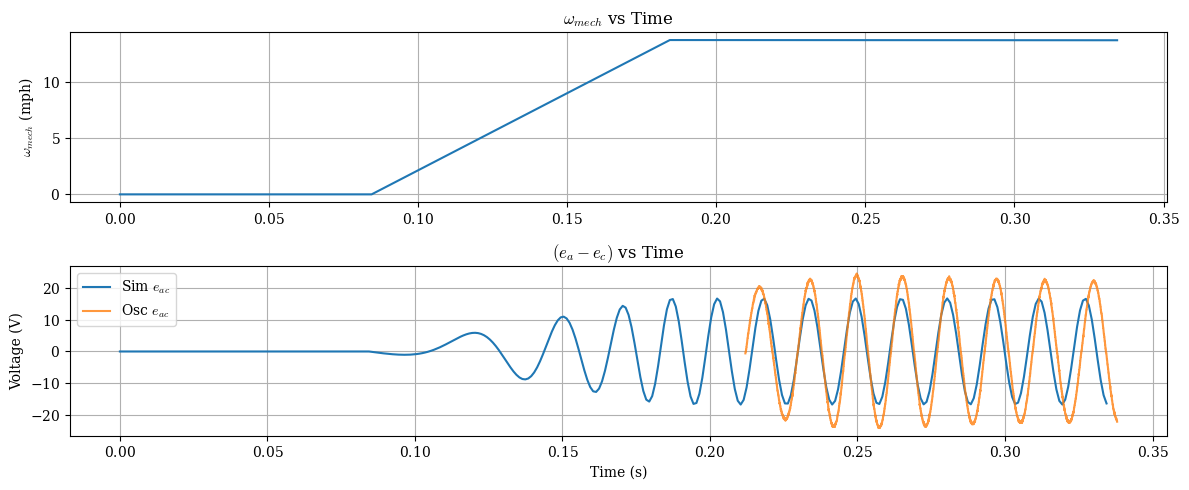

In [9]:
_t, _w, _theta, _ea, _eb, _ec, _ha, _hb, _hc = s(t, w_mech, theta_m, back_emf_a, back_emf_b, back_emf_c, hall_a, hall_b, hall_c)
_t_z = _t - _t[0]

_mask_osc = (_t_osc_z >= t0_osc) & (_t_osc_z <= t1_osc)

# Figure 1: w_mech and ea-ec overlaid with oscilloscope eac
fig1, ax1 = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

ax1[0].plot(_t_z, _w)
ax1[0].set_ylabel(r'$\omega_{mech}$ (mph)')
ax1[0].set_title(r'$\omega_{mech}$ vs Time')
ax1[0].grid(True)

ax1[1].plot(_t_z,                      _ea - _ec,          label='Sim $e_{ac}$')
ax1[1].plot(_t_osc_z[_mask_osc], eac[_mask_osc], label='Osc $e_{ac}$', alpha=0.8)
ax1[1].set_ylabel('Voltage (V)')
ax1[1].set_title(r'$(e_a - e_c)$ vs Time')
ax1[1].set_xlabel('Time (s)')
ax1[1].legend()
ax1[1].grid(True)

fig1.tight_layout()
plt.show()

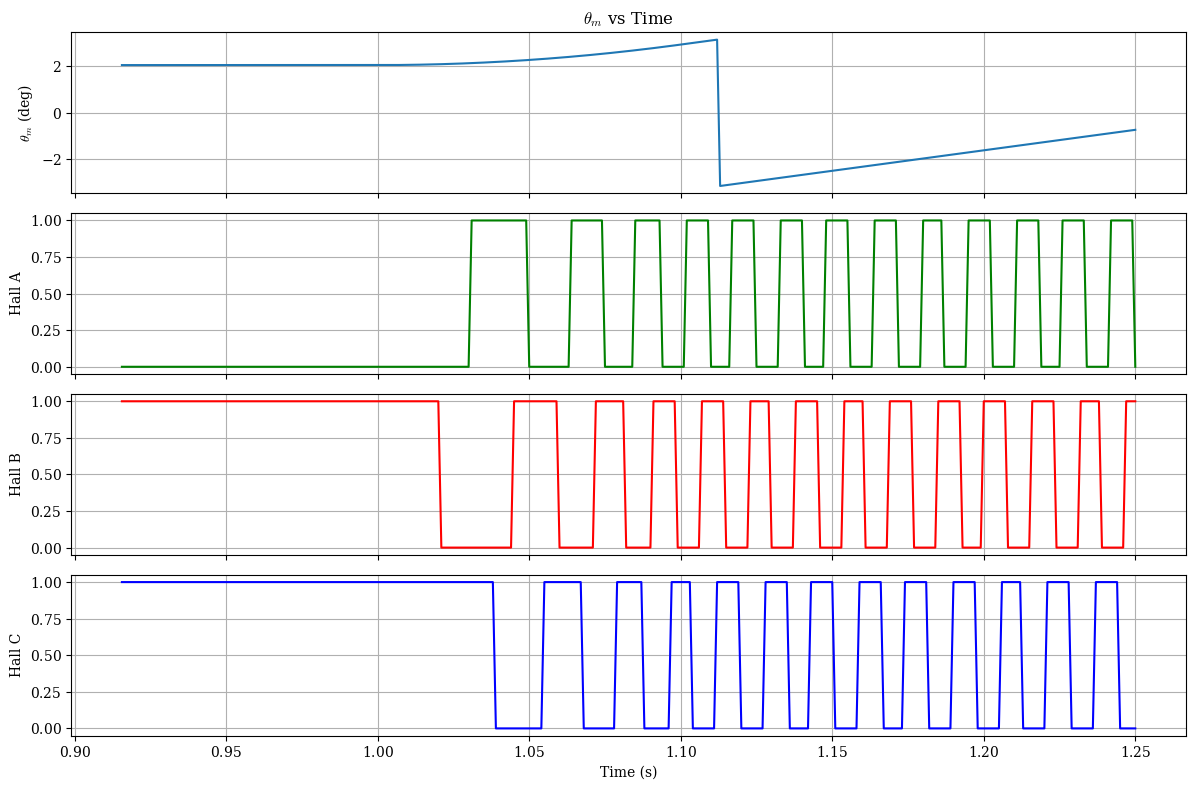

In [10]:
# Figure 2: theta_m and hall sensors
fig2, ax2 = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

ax2[0].plot(_t, _theta)
ax2[0].set_ylabel(r'$\theta_m$ (deg)')
ax2[0].set_title(r'$\theta_m$ vs Time')
ax2[0].grid(True)

ax2[1].plot(_t, _ha, color='green')
ax2[1].set_ylabel('Hall A')
ax2[1].grid(True)

ax2[2].plot(_t, _hb, color='red')
ax2[2].set_ylabel('Hall B')
ax2[2].grid(True)

ax2[3].plot(_t, _hc, color='blue')
ax2[3].set_ylabel('Hall C')
ax2[3].set_xlabel('Time (s)')
ax2[3].grid(True)

fig2.tight_layout()
plt.show()

In [11]:
def dominant_frequency(signal, time_array):
    """Returns the dominant frequency (Hz) of a signal via FFT peak detection."""
    n  = len(signal)
    dt = numpy.mean(numpy.diff(time_array))
    freqs = numpy.fft.rfftfreq(n, d=dt)
    mag   = numpy.abs(numpy.fft.rfft(signal))
    # Ignore DC (index 0)
    peak_idx = numpy.argmax(mag[1:]) + 1
    return freqs[peak_idx]

freq_sim = dominant_frequency(_ea - _ec, _t)
freq_osc = dominant_frequency(eac, t_osc)

print(f"Sim  eac frequency: {freq_sim:.2f} Hz")
print(f"Osc  eac frequency: {freq_osc:.2f} Hz")

Sim  eac frequency: 65.59 Hz
Osc  eac frequency: 60.00 Hz


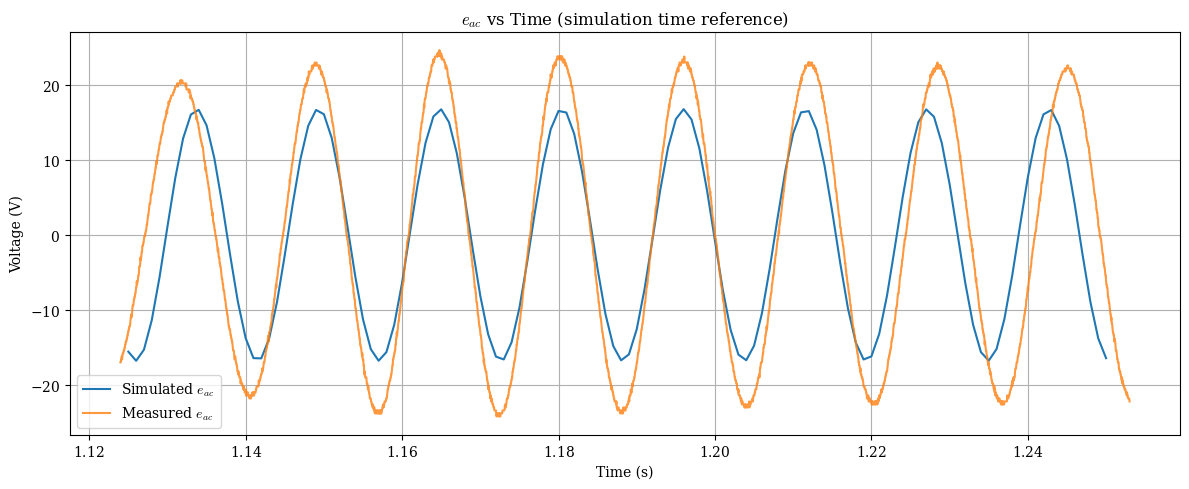

In [12]:
import matplotlib.gridspec as gridspec

# Time ranges from markdown cell
t0_sim_f, t1_sim_f = 1.124, 1.25
t0_osc_f, t1_osc_f = 0.209, 0.338

# Sim: slice to specified range
_mask_sim_f = (t >= t0_sim_f) & (t <= t1_sim_f)
t_sim_f   = t[_mask_sim_f]
eac_sim_f = (back_emf_a - back_emf_c)[_mask_sim_f]

# Osc: slice to specified range, then shift to sim time reference
_mask_osc_f = (_t_osc_z >= t0_osc_f) & (_t_osc_z <= t1_osc_f)
t_osc_f   = _t_osc_z[_mask_osc_f] - t0_osc_f + t0_sim_f
eac_osc_f = eac[_mask_osc_f]

# Compute frequencies
freq_sim_f = dominant_frequency(eac_sim_f, t_sim_f)
freq_osc_f = dominant_frequency(eac_osc_f, t_osc_f)

# Figure 4
fig4, ax4 = plt.subplots(1, 1, figsize=(12, 5))

ax4.plot(t_sim_f, eac_sim_f, label='Simulated $e_{ac}$')
ax4.plot(t_osc_f, eac_osc_f, label='Measured $e_{ac}$', alpha=0.8)
ax4.set_ylabel('Voltage (V)')
ax4.set_title(r'$e_{ac}$ vs Time (simulation time reference)')
ax4.set_xlabel('Time (s)')
ax4.legend()
ax4.grid(True)

fig4.tight_layout()
plt.show()

In [13]:
freq_sim_f = dominant_frequency(eac_sim_f, t_sim_f)
freq_osc_f = dominant_frequency(eac_osc_f, t_osc_f)

print(f"Simulated eac frequency (t={t0_sim_f}–{t1_sim_f} s): {freq_sim_f:.2f} Hz")
print(f"Measured eac frequency (t={t0_osc_f}–{t1_osc_f} s): {freq_osc_f:.2f} Hz")

Simulated eac frequency (t=1.124–1.25 s): 63.49 Hz
Measured eac frequency (t=0.209–0.338 s): 62.00 Hz


In [14]:
amp_sim_f = (eac_sim_f.max() - eac_sim_f.min()) / 2
amp_osc_f = (eac_osc_f.max() - eac_osc_f.min()) / 2

print(f"Sim eac amplitude: {amp_sim_f:.4f} V")
print(f"Osc eac amplitude: {amp_osc_f:.4f} V")

Sim eac amplitude: 16.7791 V
Osc eac amplitude: 24.4000 V
